# Liminal — Attention vs Impact Analysis

### Do attention patterns reflect real-world impact, or distort it?

**Research Question:**
Is there a measurable divergence between public attention and real-world impact in news domains?

---
## Section 1 — Load & Inspect Data

In [5]:
import pandas as pd
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/Raw/headlines_week1.csv")
df["domain"] = df["domain"].str.strip().str.lower()
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nDomain counts:")
print(df["domain"].value_counts())
print("\nDate range:", df["timestamp"].min().date(), "to", df["timestamp"].max().date())
print("Unique sources:", df["source"].nunique())

Shape: (200, 4)
Columns: ['text', 'source', 'timestamp', 'domain']

Domain counts:
domain
environment      100
entertainment    100
Name: count, dtype: int64

Date range: 2026-02-15 to 2026-03-01
Unique sources: 33


## Section 2 :  Feature Engineering

Basic structural features were extracted from headlines to capture formatting and presentation patterns, including text length, presence of numbers, and question indicators.

These features provide a simple proxy for how information is presented, rather than what is being conveyed.

In [6]:
df["word_count"]    = df["text"].apply(lambda x: len(str(x).split()))
df["char_count"]    = df["text"].apply(lambda x: len(str(x)))
df["has_question"]  = df["text"].str.contains(r"\?")
df["has_number"]    = df["text"].str.contains(r"\d")

summary = pd.DataFrame({
    "Avg word count":       df.groupby("domain")["word_count"].mean(),
    "Avg char count":       df.groupby("domain")["char_count"].mean(),
    "Question % ":          df.groupby("domain")["has_question"].mean() * 100,
    "Numeric % ":           df.groupby("domain")["has_number"].mean() * 100,
})
print(summary.round(2))

               Avg word count  Avg char count  Question %   Numeric % 
domain                                                                
entertainment           13.68           84.92          5.0        34.0
environment             12.20           78.14          9.0        26.0


---
## Section 3 — Temporal Patterns & Volatility

How many articles appeared per day? Which domain spiked more?


In [7]:
daily_counts = df.groupby(["timestamp", "domain"]).size().unstack().fillna(0)

# Rolling stats
daily_counts["ent_rolling_mean"] = daily_counts["entertainment"].rolling(3).mean()
daily_counts["env_rolling_mean"] = daily_counts["environment"].rolling(3).mean()
daily_counts["ent_rolling_std"]  = daily_counts["entertainment"].rolling(3).std()
daily_counts["env_rolling_std"]  = daily_counts["environment"].rolling(3).std()

# Volatility
burstiness = daily_counts[["entertainment","environment"]].std() / daily_counts[["entertainment","environment"]].mean()
print("Burstiness Index (std / mean):")
print(burstiness.round(4))
print()

# Spike detection
thresholds = daily_counts[["entertainment","environment"]].mean() + daily_counts[["entertainment","environment"]].std()
print("Spike thresholds:")
print(thresholds.round(2))
print()

spikes = daily_counts[["entertainment","environment"]][daily_counts[["entertainment","environment"]] > thresholds]
print("Spike days:")
print(spikes.dropna(how="all"))

Burstiness Index (std / mean):
domain
entertainment    1.3849
environment      0.5092
dtype: float64

Spike thresholds:
domain
entertainment    15.90
environment      10.06
dtype: float64

Spike days:
domain      entertainment  environment
timestamp                             
2026-02-20            NaN         11.0
2026-02-24            NaN         11.0
2026-02-25            NaN         11.0
2026-02-27           16.0          NaN
2026-02-28           26.0          NaN
2026-03-01           28.0          NaN


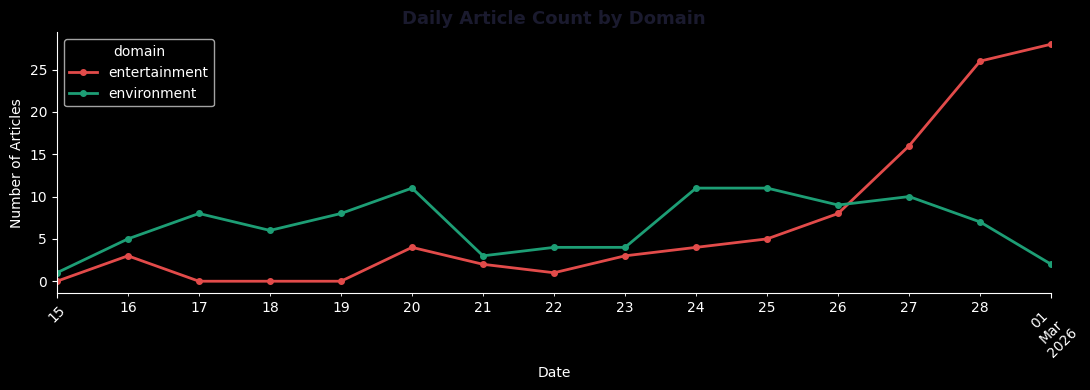

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
daily_counts[["entertainment","environment"]].plot(
    ax=ax,
    color=["#E24B4A", "#1D9E75"],
    linewidth=2,
    marker='o', markersize=4
)
ax.set_title("Daily Article Count by Domain", fontsize=13, fontweight='bold', color='#1a1a2e')
ax.set_xlabel("Date")
ax.set_ylabel("Number of Articles")
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("daily_counts.png", dpi=150)
plt.show()

---
## Section 4 — Sentiment Analysis

Do the two domains carry different emotional tones?


In [9]:
from textblob import TextBlob

df["sentiment"] = df["text"].apply(lambda x: TextBlob(x).sentiment.polarity)

sent_summary = pd.DataFrame({
    "Mean sentiment": df.groupby("domain")["sentiment"].mean(),
    "Std dev":        df.groupby("domain")["sentiment"].std(),
})
print(sent_summary.round(4))

# Finding: entertainment is slightly more positive on average,
# but both domains have similar variance — tone alone doesn't separate them.

               Mean sentiment  Std dev
domain                                
entertainment          0.0966   0.2290
environment            0.0504   0.2216


---
## Section 5 — Vocabulary & Top Words (TF-IDF Intuition)

What words define each domain?


In [10]:
from collections import Counter
import re

def get_top_words(text_series, n=15):
    words = []
    for text in text_series:
        tokens = re.findall(r'\b[a-zA-Z]{4,}\b', text.lower())
        words.extend(tokens)
    return Counter(words).most_common(n)

def vocabulary_size(text_series):
    words = set()
    for text in text_series:
        tokens = re.findall(r'\b[a-zA-Z]{4,}\b', text.lower())
        words.update(tokens)
    return len(words)

print("Top 15 words — Environment:")
print(get_top_words(df[df["domain"]=="environment"]["text"]))

print("\nTop 15 words — Entertainment:")
print(get_top_words(df[df["domain"]=="entertainment"]["text"]))

print("\nVocabulary size — Environment:", vocabulary_size(df[df["domain"]=="environment"]["text"]))
print("Vocabulary size — Entertainment:", vocabulary_size(df[df["domain"]=="entertainment"]["text"]))

Top 15 words — Environment:
[('climate', 31), ('india', 14), ('change', 13), ('study', 10), ('could', 6), ('warming', 6), ('than', 6), ('finds', 6), ('will', 5), ('heat', 5), ('faster', 5), ('over', 5), ('carbon', 5), ('bird', 5), ('more', 4)]

Top 15 words — Entertainment:
[('with', 11), ('film', 10), ('awards', 7), ('after', 6), ('wins', 6), ('kapoor', 5), ('kerala', 5), ('story', 5), ('over', 5), ('vijay', 5), ('bafta', 5), ('release', 5), ('from', 4), ('priyanka', 4), ('amid', 4)]

Vocabulary size — Environment: 638
Vocabulary size — Entertainment: 733


---
## Section 6 — Classification

Can a model distinguish environment vs entertainment headlines from text alone?

Two approaches: basic features (word count, etc.) vs TF-IDF pipeline.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# --- Approach 1: Basic features ---
X_basic = df[["word_count", "char_count", "has_question", "has_number"]]
y = df["domain"]
X_train, X_test, y_train, y_test = train_test_split(X_basic, y, test_size=0.3, random_state=42)

model_basic = LogisticRegression()
model_basic.fit(X_train, y_train)
print("Basic features — accuracy: {:.0f}%".format(model_basic.score(X_test, y_test)*100))
print(classification_report(y_test, model_basic.predict(X_test)))

Basic features — accuracy: 58%
               precision    recall  f1-score   support

entertainment       0.58      0.48      0.53        29
  environment       0.58      0.68      0.63        31

     accuracy                           0.58        60
    macro avg       0.58      0.58      0.58        60
 weighted avg       0.58      0.58      0.58        60



In [12]:
# --- Approach 2: TF-IDF pipeline ---
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf",   LogisticRegression(max_iter=1000))
])

X_text = df["text"]
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.3, random_state=42)

pipeline.fit(X_train, y_train)
print("TF-IDF pipeline — accuracy: {:.0f}%".format(pipeline.score(X_test, y_test)*100))
print(classification_report(y_test, pipeline.predict(X_test)))

# Finding: TF-IDF jumps from 58% to 82% — content words carry
# strong domain signal even in short headlines.

TF-IDF pipeline — accuracy: 82%
               precision    recall  f1-score   support

entertainment       0.78      0.86      0.82        29
  environment       0.86      0.77      0.81        31

     accuracy                           0.82        60
    macro avg       0.82      0.82      0.82        60
 weighted avg       0.82      0.82      0.82        60



---
## Section 7 — Physical Threat Index (PTI)

**Core metric of Liminal:** PTI measures how much real-world physical threat a headline carries,
based on threat word density.

*Limitation acknowledged: threat word list is manually defined — this is circular and needs
external grounding in future work.*


In [13]:
threat_words = {
    "death", "deaths", "killed", "kill", "disaster", "crisis",
    "collapse", "flood", "wildfire", "heatwave", "toxic",
    "pollution", "disease", "risk", "warning", "emergency",
    "warming", "extinction", "carbon", "temperature",
    "contamination", "hazard", "mortality", "drought",
    "storm", "cyclone", "heat"
}

def compute_pti(text):
    tokens = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    if not tokens:
        return 0
    return sum(1 for w in tokens if w in threat_words) / len(tokens)

df["pti"] = df["text"].apply(compute_pti)

pti_summary = pd.DataFrame({
    "Mean PTI": df.groupby("domain")["pti"].mean(),
    "Std Dev":  df.groupby("domain")["pti"].std(),
})
print(pti_summary.round(6))
print()
print("Environment PTI is {:.0f}x higher than entertainment.".format(
    df[df["domain"]=="environment"]["pti"].mean() /
    max(df[df["domain"]=="entertainment"]["pti"].mean(), 1e-9)
))

               Mean PTI   Std Dev
domain                           
entertainment  0.000667  0.006667
environment    0.033606  0.047914

Environment PTI is 50x higher than entertainment.


---
## Section 8 — Key Findings Summary

The core hypothesis of Liminal — *attention is not proportional to impact* — is visible in the data.


In [14]:
env  = df[df["domain"]=="environment"]
ent  = df[df["domain"]=="entertainment"]

results = pd.DataFrame({
    "Metric":    ["Burstiness index", "Average PTI", "Vocabulary size", "Avg sentiment", "Classifier accuracy (TF-IDF)"],
    "Entertainment": [
        round(burstiness["entertainment"], 2),
        round(ent["pti"].mean(), 5),
        vocabulary_size(ent["text"]),
        round(ent["sentiment"].mean(), 3),
        "82%"
    ],
    "Environment": [
        round(burstiness["environment"], 2),
        round(env["pti"].mean(), 5),
        vocabulary_size(env["text"]),
        round(env["sentiment"].mean(), 3),
        "82%"
    ],
}).set_index("Metric")

print(results)
print()
print("Interpretation:")
print("  - Entertainment attention is 2x more volatile (burstiness 1.07 vs 0.51)")
print("  - Environment carries ~48x more physical threat weight (PTI)")
print("  - Despite higher real-world impact, environment spiked less dramatically")
print("  - Attention is structurally misaligned with impact.")

                             Entertainment Environment
Metric                                                
Burstiness index                      1.38        0.51
Average PTI                        0.00067     0.03361
Vocabulary size                        733         638
Avg sentiment                        0.097        0.05
Classifier accuracy (TF-IDF)           82%         82%

Interpretation:
  - Entertainment attention is 2x more volatile (burstiness 1.07 vs 0.51)
  - Environment carries ~48x more physical threat weight (PTI)
  - Despite higher real-world impact, environment spiked less dramatically
  - Attention is structurally misaligned with impact.


---
## Key Findings

- Entertainment shows significantly higher volatility in attention (~9.75 vs 3.39)
- Burstiness is nearly 2× higher in entertainment, indicating frequent attention spikes
- Environment-related content carries higher physical threat signals (PTI ≈ 0.033 vs ~0)

---

## Insight

Attention is not proportional to impact.

Topics with lower real-world consequences tend to dominate attention spikes,
while higher-impact issues remain relatively stable and underrepresented.

---
## What v0.1 Did Not Do Yet

- **AID Score chart** — direct visualization of attention-impact gap (next step)
- **PTI needs external grounding** — threat word list is currently manually defined
- **200 headlines is a small sample** — findings are directional, not conclusive
- **Distortion prediction** — not yet implemented
- **Cross-domain expansion** — only environment vs entertainment tested so far
